## COMBINING MODELS

Combining models is made easy and intuitive through the use of linear operators such as `+`, `-`, `/`, and `*`, which behave exactly like the normal operators we know and love. To start this tutorial, let's create two different models and see how we can combine them.


In [1]:
from zoo import Fittable1D
import numpy as np

# defining our simple models

class Gaussian1D(Fittable1D):
    @staticmethod
    def evaluate(x, amp, x0, stddev):
        return amp * np.exp(-0.5 * (x - x0) ** 2 / stddev**2)
    
class Line1D(Fittable1D):
    @staticmethod
    def evaluate(x, a, b):
        return a*x +  b
    

#NOTE I'll add values for some parameter
gaussian = Gaussian1D(
    name = 'MyGaussian',
    amp=10,
    x0= 5
)

line = Line1D(
    name = 'MyLine',
    a = .5
)

In [2]:
print(gaussian)

print(line)

MODEL NAME: MyGaussian 
FREE PARAMS: 3
GRID VARIABLES: ['x']
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS              
______________________________________________________________________
0    amp             10.00      0          (-inf, inf)         
1    x0              5.00       0          (-inf, inf)         
2    stddev          1.00       0          (-inf, inf)         

MODEL NAME: MyLine 
FREE PARAMS: 2
GRID VARIABLES: ['x']
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS              
______________________________________________________________________
0    a               0.50       0          (-inf, inf)         
1    b               1.00       0          (-inf, inf)         



now we can plot the two models separately to see both of them

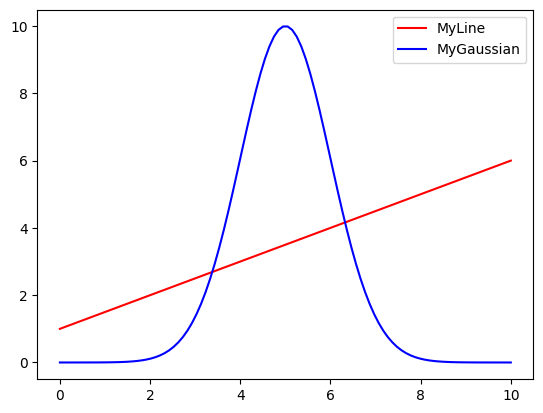

In [3]:
import matplotlib.pyplot as plt 

X = np.linspace(0,10, 100)

line_values = line.evaluate(X)

gaussian_values = gaussian.evaluate(X)


plt.plot(X, line_values, c='r', label=line.name)
plt.plot(X, gaussian_values, c='b', label=gaussian.name)
plt.legend()
plt.show()

Now we can combine the two models simply by using the previously mentioned linear operators.



**Note**

In the case of division `/` always means floating point division–integer division and the `//` operator is currently not supported for models.

for models that have a single output, the result of evaluating a model like `A + B` is to evaluate `A` and `B` separately on the given input, and then return the sum of the outputs of `A` and `B`. This requires that `A` and `B` take the same number of inputs and both have a single output.


In [4]:
summed_model = line + gaussian

summed_model.name = 'Summed Model'

print(summed_model)

COMPOSITE MODEL NAME: Summed Model 
CONTAINED MODELS: ['MyLine', 'MyGaussian']
GRID VARIABLES: ['x']
LOGIC: (MyLine [0] + MyGaussian [1])
FREE PARAMS: 5
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS               
______________________________________________________________________
0    a_0             0.50       0          (-inf, inf)         
1    b_0             1.00       0          (-inf, inf)         
2    amp_1           10.00      0          (-inf, inf)         
3    x0_1            5.00       0          (-inf, inf)         
4    stddev_1        1.00       0          (-inf, inf)         



When printing the composite other important informations are displayed, like the __LOGIC__ that define the model (i.e. the operations that link the submodel and the names of the submodels)  

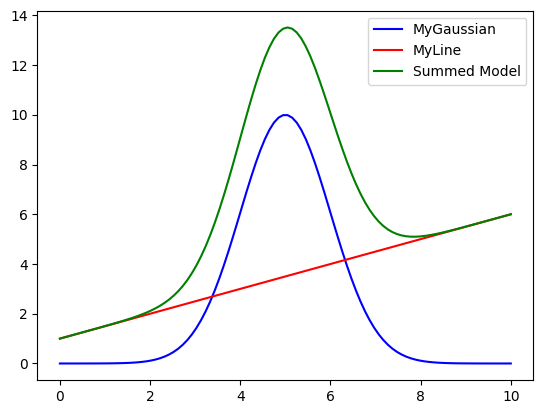

In [5]:
composite_values = summed_model.evaluate(X)

# I will plot previous values for line and gaussian
plt.plot(X, gaussian_values, c="b", label=gaussian.name)
plt.plot(X, line_values, c="r", label=line.name)
plt.plot(X, composite_values, c="g", label=summed_model.name)
plt.legend()
plt.show()

A Composite Model behave like a normal FittableModel, meaning all operations presented in the other tutorial will work in the same way

**IMPORTANT**: Creating a composite model by combining two simpler models always creates a copy! This means that changes to individual models do not affect the composite model and vice versa.


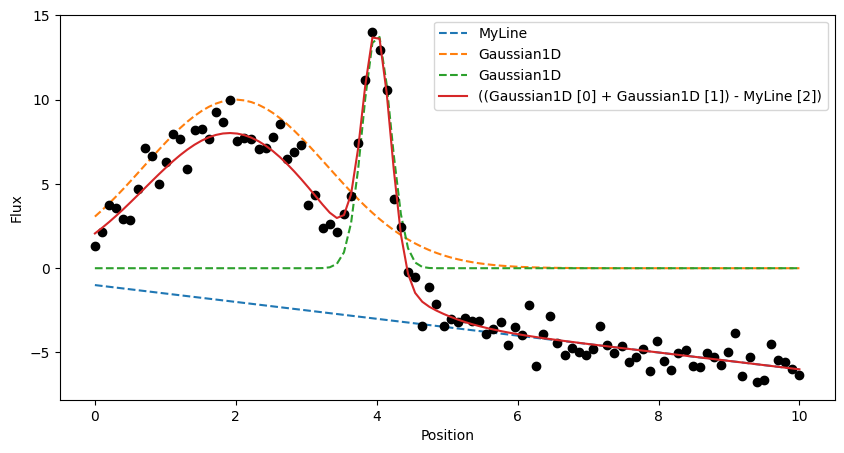

In [51]:
# Generate fake data

g1 = Gaussian1D(amp=10, x0=2, stddev=1.3)
g2 = Gaussian1D(amp=14, x0=4, stddev=0.2)


# random composite model
g1_g2 = (g1 + g2) - line


y = g1_g2([X]) + np.random.normal(0.0, 1, X.shape)

# Plot the data with the best-fit model
plt.figure(figsize=(10, 5))
plt.plot(X, -line([X]), linestyle="--", label=line.name)
plt.plot(X, g1([X]), linestyle="--", label=g1.name)
plt.plot(X, g2([X]), linestyle="--", label=g2.name)
plt.plot(X, y, "ko")
plt.plot(X, g1_g2([X]), label=g1_g2.composite_structure())
plt.legend()
plt.xlabel("Position")
plt.ylabel("Flux")
plt.show()

In [36]:
print(g1_g2)

COMPOSITE MODEL NAME: CompositeModel 
CONTAINED MODELS: ['Gaussian1D', 'Gaussian1D', 'MyLine']
GRID VARIABLES: ['x']
LOGIC: ((Gaussian1D [0] + Gaussian1D [1]) - MyLine [2])
FREE PARAMS: 8
______________________________________________________________________
     NOME            VALORE     FREEZE     BOUNDS               
______________________________________________________________________
0    amp_0           10.00      0          (-inf, inf)         
1    x0_0            2.00       0          (-inf, inf)         
2    stddev_0        1.30       0          (-inf, inf)         
3    amp_1           14.00      0          (-inf, inf)         
4    x0_1            4.00       0          (-inf, inf)         
5    stddev_1        0.20       0          (-inf, inf)         
6    a_2             0.50       0          (-inf, inf)         
7    b_2             1.00       0          (-inf, inf)         



The last binary operator that can be used to create compound models is the composition operator, also known as the “pipe” operator `|` (not to be confused with the boolean “or” operator that this implements for Python numeric objects). A model created with the composition operator like `M = F | G`, when evaluated, is equivalent to evaluating `G(F(...))`.


### THE FOLLOWING EXAMPLE IS INSPIRED BY ASTROPY:

#### REDSHIFT SCALING FACTOR USING MODEL 


We can see an example of model composition given the operator __'|'__: we define ou simple redshift factor as a model
with a single input (the grid or the results) and compose a secondary model (e.g our gaussian) to see how model composition works

In [6]:
from zoo import Kernel1D

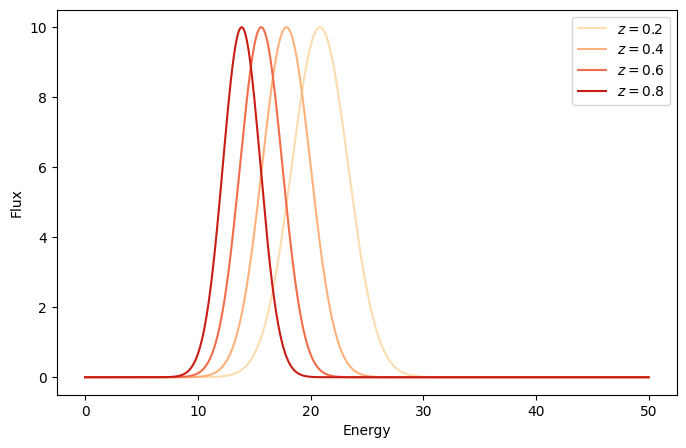

In [11]:


Xx = np.linspace(0,50,1000)

gaussian['x0'].value = 25
gaussian['stddev'].value = 3

class RedshiftFactor(Kernel1D):
    def __init__(self, z):        
        self.z = z

    def evaluate(self, data):
        return data * (1 + self.z)


plt.figure(figsize=(8, 5))

for z in (0.2, 0.4, 0.6, 0.8):
    g = RedshiftFactor(z) | gaussian 

    plt.plot(Xx, g.evaluate(Xx), color=plt.cm.OrRd(z), label=f"$z={z}$")


plt.xlabel("Energy")
plt.ylabel("Flux")
plt.legend()
plt.show()

OR...you can write your own inversed Scalefactor

If you wish to perform redshifting in the wavelength space instead of energy, and would also like to conserve flux, here is another way to do it using the inverse of the model

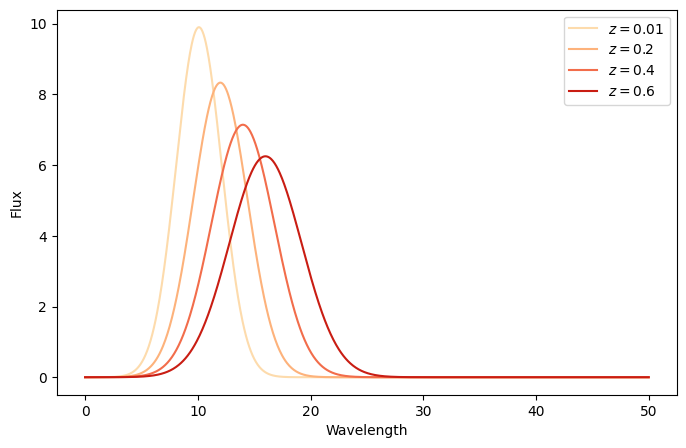

In [15]:
class InversedRedshiftFactor(Kernel1D):
    def __init__(self, z, **kwargs):
        super().__init__(**kwargs)

        self.z = z

    def evaluate(self, data):
        z = 1.0 / (1.0 + self.z) - 1.0
        return data * (1 + z)


#gaussian['x0'].value = 10

plt.figure(figsize=(8, 5))

for z in (0.01, 0.2, 0.4, 0.6):
    g = InversedRedshiftFactor(z) | Gaussian1D(amp=10, x0=10, stddev=2) | InversedRedshiftFactor(z)

    plt.plot(Xx, g.evaluate(Xx), color=plt.cm.OrRd(z + 0.2), label=f"$z={z}$")


plt.xlabel("Wavelength")
plt.ylabel("Flux")
plt.legend()
plt.show()